In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd

train = pd.read_csv('../data/train.csv')
store = pd.read_csv('../data/store.csv')

print(train.shape)
print(store.shape)
train.head()

(1017209, 9)
(1115, 10)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [4]:
train.isnull().sum()

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

In [5]:
store.isnull().sum()

Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

In [6]:
print(train.duplicated().sum())


0


In [7]:
print(store.duplicated().sum())

0


In [8]:
train.describe()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00


In [9]:
train['Date'] = pd.to_datetime(train['Date'])
print(train['Date'].dtype)
print(train['Date'].min(), train['Date'].max())


datetime64[ns]
2013-01-01 00:00:00 2015-07-31 00:00:00


In [10]:
print("Before:", train.shape)
train = train[train['Open'] == 1]
print("After:", train.shape)

Before: (1017209, 9)
After: (844392, 9)


In [11]:
print(train['StateHoliday'].unique())

['0' 'a' 'b' 'c' 0]


In [12]:
train['StateHoliday'] = train['StateHoliday'].astype(str)
print(train['StateHoliday'].unique())

['0' 'a' 'b' 'c']


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

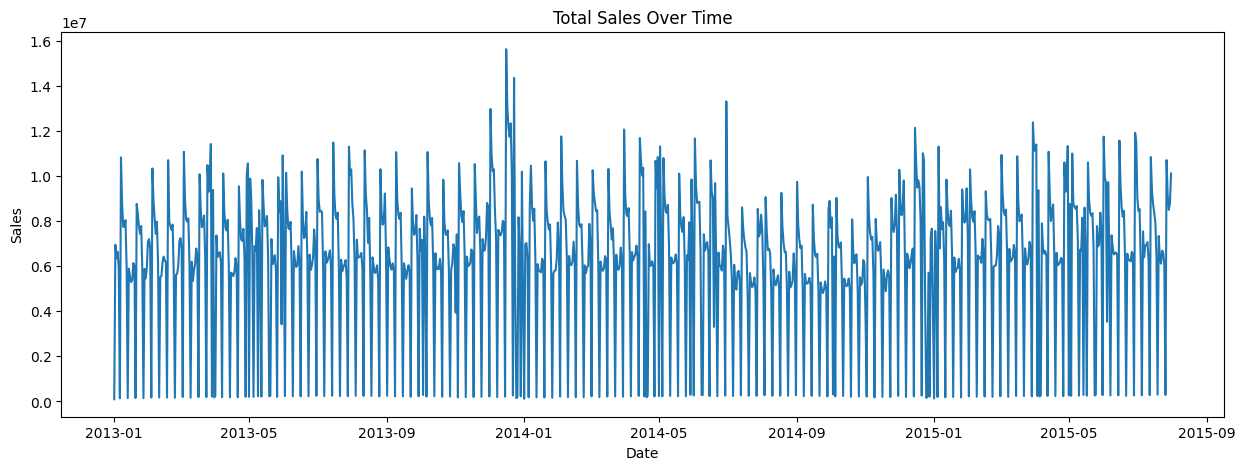

In [14]:
daily_sales = train.groupby('Date')['Sales'].sum()

plt.figure(figsize=(15, 5))
plt.plot(daily_sales.index, daily_sales.values)
plt.title('Total Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

### Key Observations

### 1. Sales Over Time
- Dataset spans Jan 2013 – Jul 2015
- Clear seasonal spikes visible, especially around December each year
- Sales trend appears relatively stable across the period

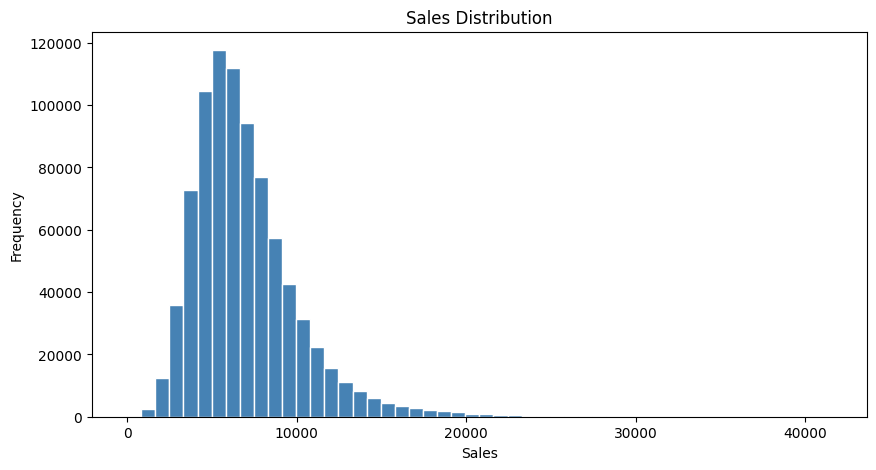

In [15]:
plt.figure(figsize=(10, 5))
plt.hist(train['Sales'], bins=50, color='steelblue', edgecolor='white')
plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

### 2. Sales Distribution
- Right-skewed distribution — most stores sell between 3,000–9,000/day
- Mean sales: ~5,773 | Median: ~5,744 (close — not heavily skewed)
- Max sale recorded: 41,551 (likely a holiday or special event)

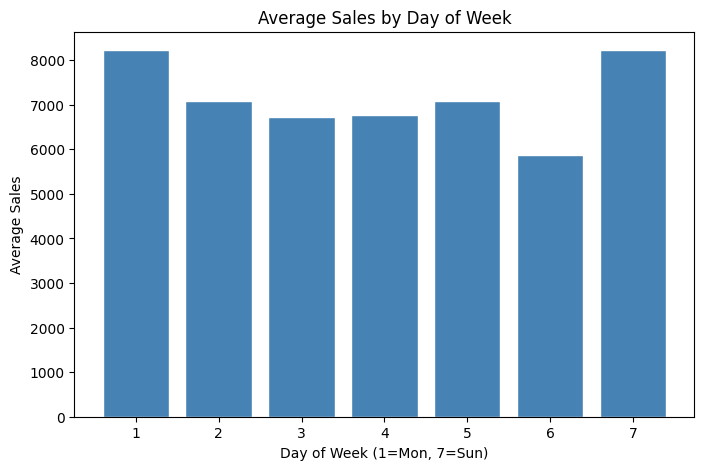

In [16]:
day_sales = train.groupby('DayOfWeek')['Sales'].mean()

plt.figure(figsize=(8, 5))
plt.bar(day_sales.index, day_sales.values, color='steelblue', edgecolor='white')
plt.title('Average Sales by Day of Week')
plt.xlabel('Day of Week (1=Mon, 7=Sun)')
plt.ylabel('Average Sales')
plt.show()

### 3. Day of Week Pattern
- Monday (1) and Sunday (7) have highest average sales
- Saturday (6) consistently the lowest
- Suggests weekend shopping behavior with Monday recovery effect

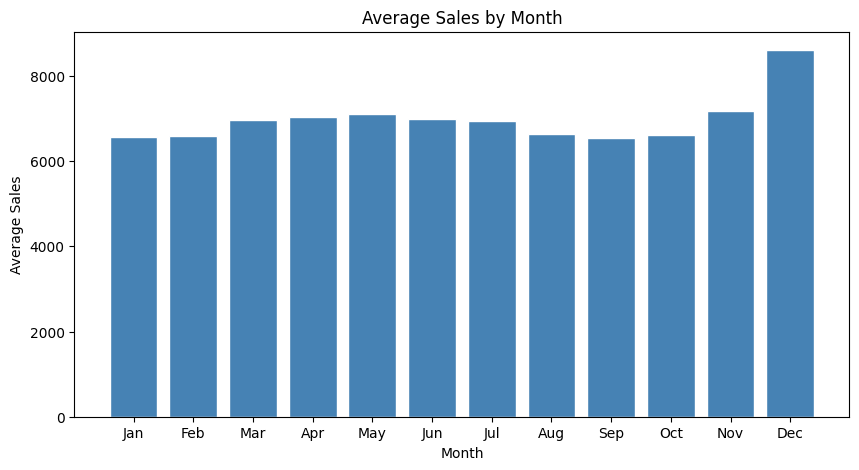

In [17]:
train['Month'] = train['Date'].dt.month

month_sales = train.groupby('Month')['Sales'].mean()

plt.figure(figsize=(10, 5))
plt.bar(month_sales.index, month_sales.values, color='steelblue', edgecolor='white')
plt.title('Average Sales by Month')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.show()

### 4. Monthly Pattern
- December is the peak month (~8,600 avg) — Christmas effect
- July/August show mid-year dip
- Strong seasonality — important feature for the model

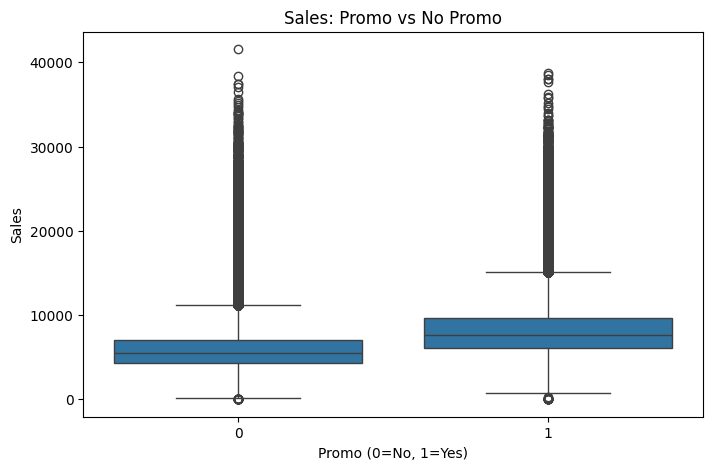

In [18]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Promo', y='Sales', data=train)
plt.title('Sales: Promo vs No Promo')
plt.xlabel('Promo (0=No, 1=Yes)')
plt.ylabel('Sales')
plt.show()

### 5. Promo Impact
- Promo days: median ~7,500 vs non-promo ~5,500
- Clear sales lift from promotions
- Promo will be a strong predictor in the model

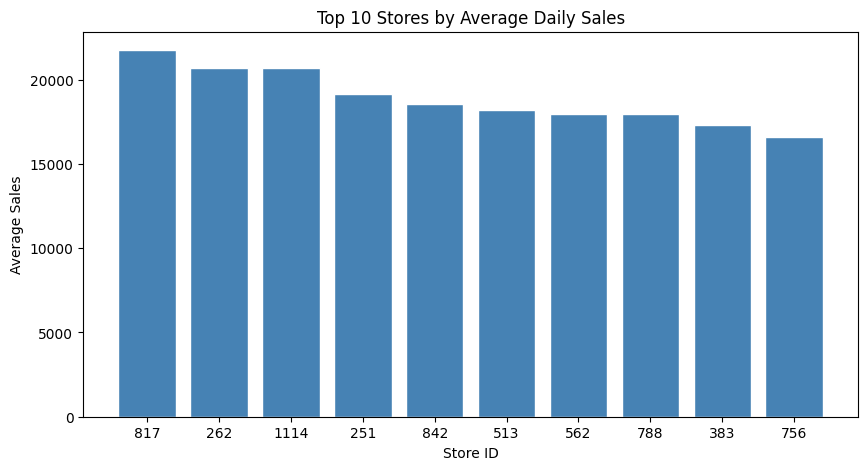

In [19]:
top_stores = train.groupby('Store')['Sales'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_stores.index.astype(str), top_stores.values, color='steelblue', edgecolor='white')
plt.title('Top 10 Stores by Average Daily Sales')
plt.xlabel('Store ID')
plt.ylabel('Average Sales')
plt.show()

### 6. Store Variability
- Top store (817) averages ~22,000/day — 3x the overall average
- High variance across stores — store ID will be an important feature

In [20]:
train = train.merge(store, on='Store', how='left')
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Month,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,7,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,7,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,7,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,7,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,7,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


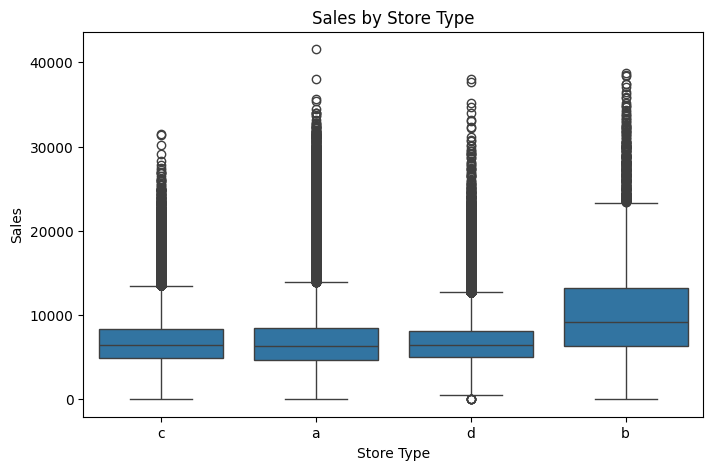

In [21]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='StoreType', y='Sales', data=train)
plt.title('Sales by Store Type')
plt.xlabel('Store Type')
plt.ylabel('Sales')
plt.show()

### 7. Sales by Store Type
- Store Type b significantly outperforms all others (avg 10,000+)
- Types a, c, d cluster around 5,000–8,000
- Store type is an important categorical feature

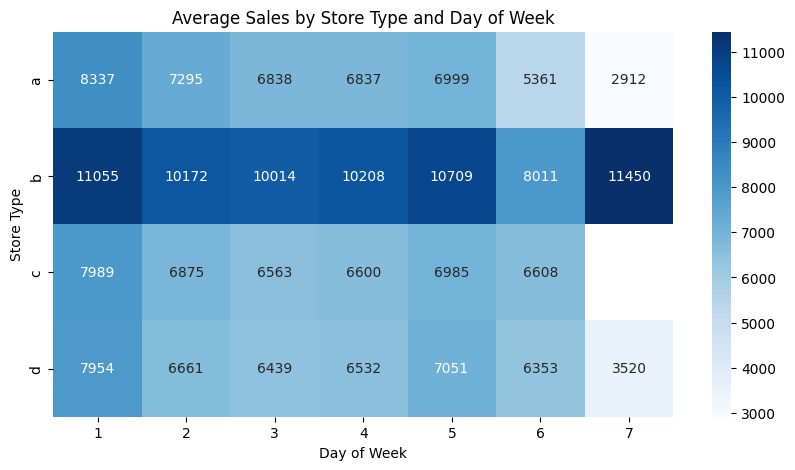

In [22]:
heatmap_data = train.groupby(['StoreType', 'DayOfWeek'])['Sales'].mean().unstack()

plt.figure(figsize=(10, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='Blues')
plt.title('Average Sales by Store Type and Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Store Type')
plt.show()

### 8. Store Type × Day of Week
- Store b maintains dominance across all days
- Store c shows no Sunday data (always closed)
- Interaction between store type and day could be a useful feature

In [23]:
train.isnull().sum()

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
Month                             0
StoreType                         0
Assortment                        0
CompetitionDistance            2186
CompetitionOpenSinceMonth    268619
CompetitionOpenSinceYear     268619
Promo2                            0
Promo2SinceWeek              423307
Promo2SinceYear              423307
PromoInterval                423307
dtype: int64

In [24]:
train['CompetitionDistance'].fillna(train['CompetitionDistance'].median(), inplace=True)
train['CompetitionOpenSinceMonth'].fillna(0, inplace=True)
train['CompetitionOpenSinceYear'].fillna(0, inplace=True)
train['Promo2SinceWeek'].fillna(0, inplace=True)
train['Promo2SinceYear'].fillna(0, inplace=True)
train['PromoInterval'].fillna('None', inplace=True)

print(train.isnull().sum().sum())

0


In [28]:
train.to_csv('../data/train_cleaned.csv', index=False)
print("Saved!")

Saved!
